In [1]:
import pandas as pd

df = pd.read_csv("/content/US_Accidents_March23[1].csv")
df.head()

/tmp/ipykernel_14297/4184527784.py:3: DtypeWarning: Columns (29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/US_Accidents_March23[1].csv")


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25240 entries, 0 to 25239
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     25240 non-null  object 
 1   Source                 25240 non-null  object 
 2   Severity               25240 non-null  int64  
 3   Start_Time             25240 non-null  object 
 4   End_Time               25240 non-null  object 
 5   Start_Lat              25240 non-null  float64
 6   Start_Lng              25240 non-null  float64
 7   End_Lat                0 non-null      float64
 8   End_Lng                0 non-null      float64
 9   Distance(mi)           25240 non-null  float64
 10  Description            25240 non-null  object 
 11  Street                 25240 non-null  object 
 12  City                   25240 non-null  object 
 13  County                 25240 non-null  object 
 14  State                  25240 non-null  object 
 15  Zi

In [3]:
# Drop unnecessary missing rows
df = df.dropna(subset=['Weather_Condition', 'Start_Time'])

# Convert time column
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

# Extract hour
df['Hour'] = df['Start_Time'].dt.hour

**`Accidents by Hour `**

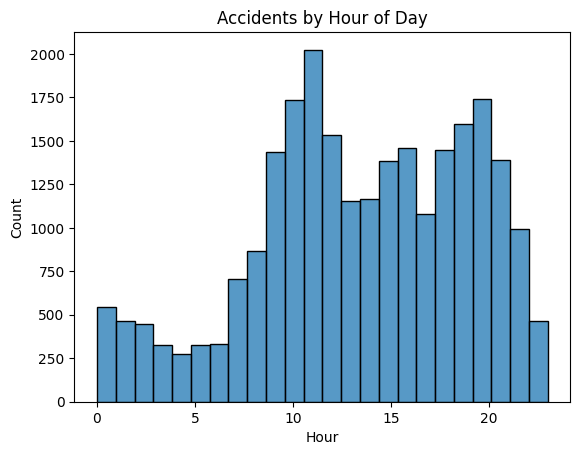

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Hour'], bins=24)
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

**` Accidents by Weather`**

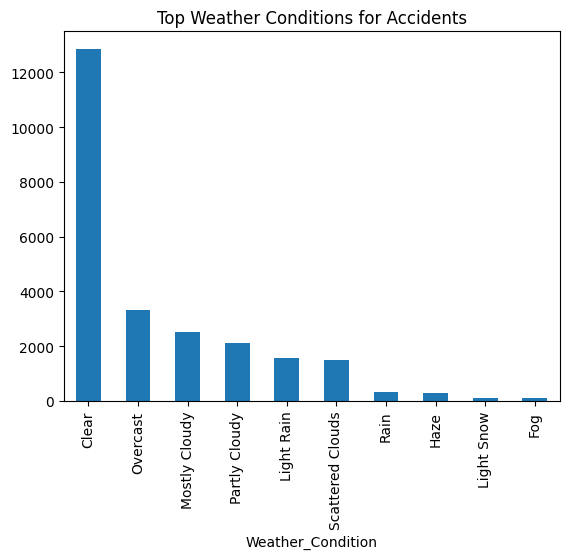

In [5]:
top_weather = df['Weather_Condition'].value_counts().head(10)

top_weather.plot(kind='bar')
plt.title("Top Weather Conditions for Accidents")
plt.show()

**`Accidents by Severity`**

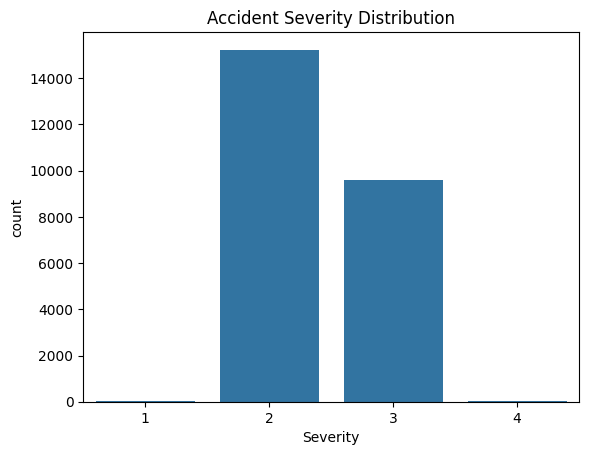

In [6]:
sns.countplot(x='Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()

 **`Hotspot Visualization `**

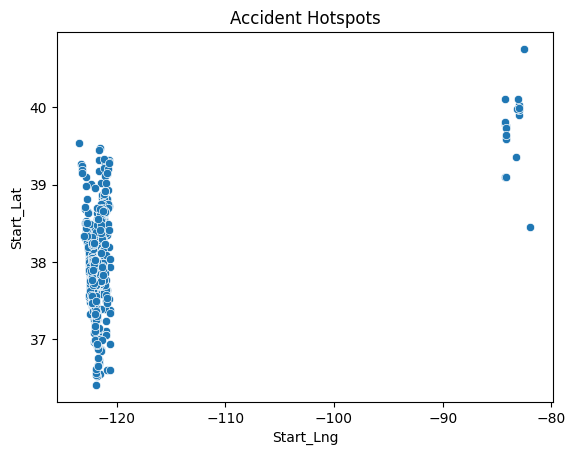

In [7]:
sns.scatterplot(x='Start_Lng', y='Start_Lat', data=df.sample(1000))
plt.title("Accident Hotspots")
plt.show()

**`Accident Map`**

In [13]:
import folium

m = folium.Map(
    location=[df['Start_Lat'].mean(), df['Start_Lng'].mean()],
    zoom_start=5
)

for i in df.sample(1000).index:
    folium.CircleMarker(
        location=[df.loc[i, 'Start_Lat'], df.loc[i, 'Start_Lng']],
        radius=2
    ).add_to(m)

m

**`Heatmap`**

In [14]:
from folium.plugins import HeatMap

heat_data = sample_df[['Start_Lat', 'Start_Lng']].values.tolist()

HeatMap(heat_data).add_to(map_accidents)

map_accidents

## Insights

The analysis of traffic accident data revealed that accidents are more frequent during certain hours of the day, particularly during peak traffic times.

Weather conditions such as rain, fog, and cloudy conditions contribute significantly to accidents.

The severity distribution shows that most accidents fall under moderate severity levels.

The hotspot visualization indicates that accidents are concentrated in specific geographic locations, highlighting areas that require improved road safety measures.

Overall, this analysis helps in understanding key factors influencing road accidents and can assist in improving traffic management and safety.
## Hotspot Analysis

The map visualization shows that accidents are concentrated in specific geographic regions. High-density areas indicate accident hotspots, which may be due to heavy traffic, urban areas, or poor road conditions.